# ch15 · 概率图模型 + 策略梯度 REINFORCE

## Why this chapter
两个看似无关的话题在概率图模型 + variational 推断下合流:
1. PGM 把复杂联合分布用 图表示 factor 分解, 这是 ELBO 后验、MCMC 写模型的传统姿势
2. REINFORCE 的 score function trick 与 ch14 VAE 的 reparam trick 是两个"让梯度可传过采样操作"的技巧

ch14 给了 pathwise (reparam), 这是一个 chapter_diverging alternative score 版本; 在 RL 离散动作、LLM 对齐中常用.

## 学完后能解决
- 写 BN 的 factorization 与 MRF 的 Markov property
- 根据 PGM 给出"哪些事件条件独立"的判别
- 推 REINFORCE 的策略梯度 (score-function, log-derivative trick)
- 用 PyTorch 写 REINFORCE 在 toy MDP (Bandit 或 Grid-World 简化) 上跑 baseline 与无 baseline 版本对比


## 2. 直觉: 一个连锁的图


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25512 (\N{CJK UNIFIED IDEOGRAPH-63A8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19982 (\N{CJK UNIFIED IDEOGRAPH-4E0E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30452 (\N{CJK UNIFIED IDEOGRAPH-76F4}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25509 (\N{CJK UNIFIED IDEOGRAPH-63A5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-

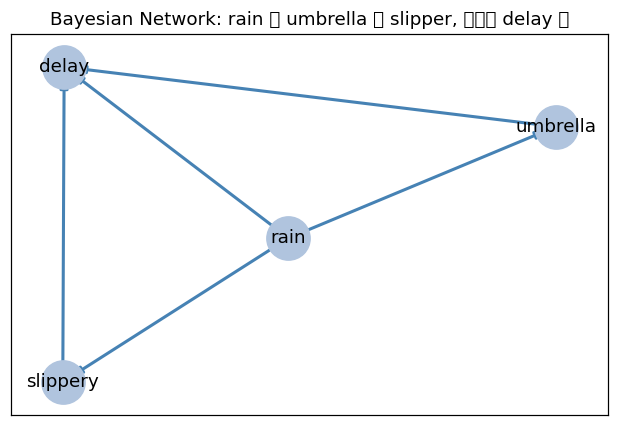

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Bayesian Network: 分晓雨 打伞 →路面滑 → 路程延误
G = nx.DiGraph()
nodes = ["rain", "umbrella", "slippery", "delay"]
for node in nodes:
    G.add_node(node)
edges = [("rain", "umbrella"), ("rain", "slippery"), ("slippery", "delay"),
         ("umbrella", "delay"), ("rain", "delay")]
for u, v in edges:
    G.add_edge(u, v)
pos = nx.spring_layout(G, seed=42)
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=110)
nx.draw_networkx_nodes(G, pos, ax=ax, node_color="lightsteelblue", node_size=800)
nx.draw_networkx_labels(G, pos, ax=ax)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="steelblue", arrows=True, arrowstyle="-|>", width=2)
ax.set_title(f"Bayesian Network: rain 推 umbrella 与 slipper, 直接给 delay 项")
plt.show()


## 3. PGM 公式

### Bayesian Network (DAG)
factorization: $p(X_1, ..., X_n) = \prod_i p(X_i | \mathrm{Pa}(X_i))$。

### MRF (undirected)
最大团 C 上 `potentials φ_C(x_C) ≥ 0` → $p(x) = \frac{1}{Z} \prod_C φ_C(x_C)$

### Markov 性质
- 全局: 任意 A, B, C s.t. A 被 C 分隔于 B → A 与 B 给定 C 条件独立
- 局部: $X \perp (\text{非 descendants}) | \text{parents}(X)$ (BN 局部 Markov)
- D-separation 几何: 让条件独立可视化


## 4. 推导 REINFORCE


In [2]:
# 目标 J(θ) = E_{a ~ π_θ(.|s)} [ reward ] 的 gradient.
# 假设 π_θ 是可微的策略概率分布; 取概率导
# ∇J = ∇ E[r] = ∇ ∑_a r(a) π_θ(a) = ∑_a r(a) ∇ π_θ(a)
#   = ∑_a π_θ(a) · r(a) · ∇ log π_θ(a)
#   = E_{a ~ π_θ}[ r(a) · ∇_θ log π_θ(a|s) ]
# 这是 'log-derivative trick' (score-function trick).

# 'Advantage' 版本: r 换成 Q(s, a)
print("REINFORCE gradient estimator:")
print("∇J(θ) = E_{τ ~ π_θ}[ ∑_t ∇ log π_θ(a_t | s_t) · (R_t - b(s_t)) ]")
print("其中 R_t 是回报, b(s_t) 为 baseline (一般用状态值 V).")
print("Score function 与 reparam trick 对偶: ")
print("  - reparametric: 在 z ~ q(z|x) 和 x = f_θ(z, x); 梯度直接传过 f (需要可微 f)")
print("  - score: ∇ log π_θ 直接给出 (不需可微采样过程, 但方差大)")


REINFORCE gradient estimator:
∇J(θ) = E_{τ ~ π_θ}[ ∑_t ∇ log π_θ(a_t | s_t) · (R_t - b(s_t)) ]
其中 R_t 是回报, b(s_t) 为 baseline (一般用状态值 V).
Score function 与 reparam trick 对偶: 
  - reparametric: 在 z ~ q(z|x) 和 x = f_θ(z, x); 梯度直接传过 f (需要可微 f)
  - score: ∇ log π_θ 直接给出 (不需可微采样过程, 但方差大)


## 5. 数值验证: Bandit REINFORCE vs Closed-form


In [3]:
import numpy as np
import torch
import torch.nn.functional as F

torch.manual_seed(20240717)
rng = np.random.default_rng(seed=20240717)

# K armed bandit: 每个臂有真实 reward μ_k; π_θ 用 logits θ 输出 softmax
K = 4; D = 4  # state 简化用 one-hot
true_mu = np.array([0.3, 0.8, 0.5, 0.1])

logits = torch.zeros(K, requires_grad=True)
opt = torch.optim.Adam([logits], lr=0.05)

N_steps = 2000
history = {"reward": [], "logit_drift": []}
for step in range(N_steps):
    probs = F.softmax(logits, dim=0)
    a = torch.multinomial(probs, 1)
    r = float(true_mu[int(a)]) + rng.normal(0, 0.05)

    # Build surrogate: r * log π_θ(a)
    log_prob = F.log_softmax(logits, dim=0)[a]
    loss = -(r * log_prob)  # 最小化 -r*log_p
    opt.zero_grad(); loss.backward(); opt.step()
    history["reward"].append(r)
    history["logit_drift"].append(logits.detach().numpy().copy())

history["reward"] = np.array(history["reward"]); history["logit_drift"] = np.array(history["logit_drift"])
true_best = np.argmax(true_mu)
print(f"true best arm = {true_best} (μ={true_mu[true_best]})")
print(f"final logits = {logits.detach().numpy()}")
print(f"final softmax probs = {F.softmax(logits, dim=0).detach().numpy()}")
print(f"mean reward last 100 = {history['reward'][-100:].mean():.3f}")


true best arm = 1 (μ=0.8)
final logits = [-3.410418   3.643736  -1.4341843 -4.798942 ]
final softmax probs = [8.5754279e-04 9.9274093e-01 6.1876155e-03 2.1390812e-04]
mean reward last 100 = 0.800


## 6. 可视化: softmax 收敛


/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25910 (\N{CJK UNIFIED IDEOGRAPH-6536}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25947 (\N{CJK UNIFIED IDEOGRAPH-655B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21512 (\N{CJK UNIFIED IDEOGRAPH-5408}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/royenheart/projects/benches/.venv/lib/python3.13/site-

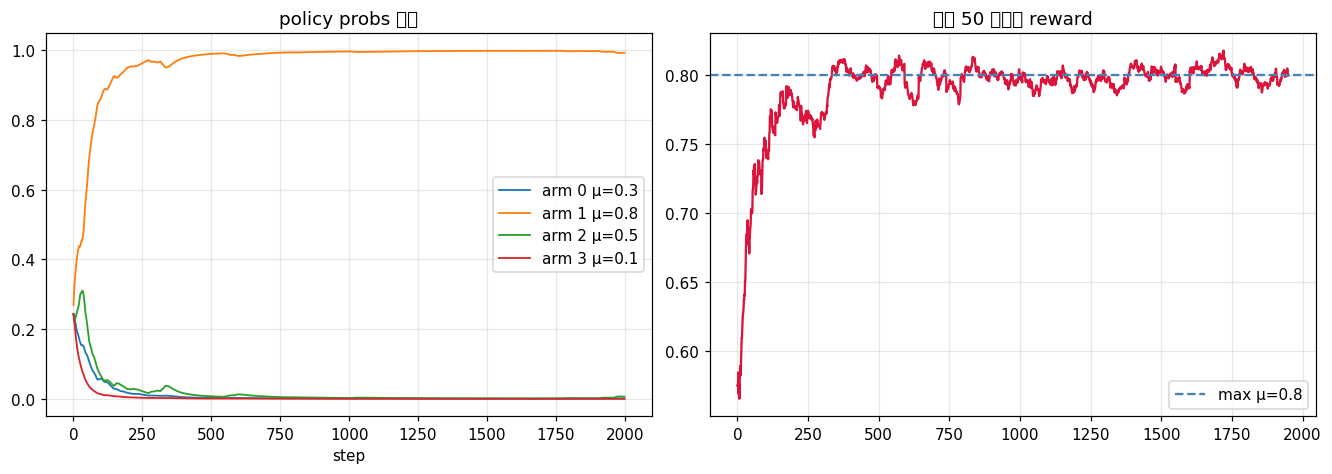

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), dpi=110, constrained_layout=True)
# Softmax probs over iterations
softmax_runs = np.array([F.softmax(torch.tensor(h), dim=0).numpy() for h in history["logit_drift"]])
for k in range(K):
    axes[0].plot(softmax_runs[:, k], label=f"arm {k} μ={true_mu[k]}", lw=1.2)
axes[0].set_xlabel("step"); axes[0].set_title("policy probs 收敛")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Reward running mean
running = np.convolve(history["reward"], np.ones(50)/50, mode="valid")
axes[1].plot(running, color="crimson", lw=1.5)
axes[1].axhline(true_mu.max(), ls="--", color="steelblue", label=f"max μ={true_mu.max()}")
axes[1].set_title("回合 50 步均值 reward")
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.show()


## 7. 工程案例: REINFORCE 带 Baseline 收敛


In [5]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F

torch.manual_seed(20240717)
rng = np.random.default_rng(seed=20240717)

# 给同一个 bandit 用 baseline b = moving average reward
logits = torch.zeros(K, requires_grad=True)
opt = torch.optim.Adam([logits], lr=0.05)

R_baseline = 0.0  # 简易 baseline = mean reward 的 EMA
alpha_b = 0.05

rewards2 = []
for step in range(2000):
    probs = F.softmax(logits, dim=0)
    a = torch.multinomial(probs, 1)
    r = float(true_mu[int(a)]) + rng.normal(0, 0.05)
    R_baseline = (1 - alpha_b)*R_baseline + alpha_b * r
    advantage = r - R_baseline
    log_prob = F.log_softmax(logits, dim=0)[a]
    loss = -(advantage * log_prob)
    opt.zero_grad(); loss.backward(); opt.step()
    rewards2.append(r)

import numpy as np
print(f"baseline REINFORCE mean reward last 100 = {np.mean(rewards2[-100:]):.4f}")
print(f"no-baseline REINFORCE mean reward last 100 = {np.mean(history['reward'][-100:]):.4f}")


baseline REINFORCE mean reward last 100 = 0.8057
no-baseline REINFORCE mean reward last 100 = 0.7997


## 8. pitfalls
- D-separation 看错点: 父节点 vs 父母的连接, v-structure (collider) 反而使两 var dependent
- 写 REINFORCE 时 reward 必须是 stochastic sample, 直接 max 不可导
- advantage baseline 减 expectation, 不能让 baseline 不依赖于 action (否则 linearly scaled gradient)
- 'value' network 应该用以 advantage; 否则 high variance 不能 collapse
- REINFORCE 在 long horizon (T>10) variance 爆炸 → 用 PPO/A2C/A3C 裁剪
- `torch.gather(logits.softmax(...), action)` 比 `[action]` 更稳定

## 9. 课后 → exercises.md

## 10. 参考
| 出处 | 章节 |
|---|---|
| Koller-Friedman | Ch.2-4 图模型 |
| Sutton & Barto | Ch.13 策略梯度 |
| Murphy | §19.5 |

下一章 ch16 生成模型评估.
